In [41]:
#  loading the public model (JECS BMI)
library(DynamicPGS)
data(adata_jecs_public)

# lead - proxy variant table
head(adata_jecs_public$proxy)

,lead_var,proxy_var,ld_r
,<chr>,<chr>,<dbl>
1,chr1:65435436:T:C,chr1:65435436:T:C,1.000000
2,chr1:65435436:T:C,chr1:65429581:A:G,0.998255
3,chr1:65435436:T:C,chr1:65429447:A:G,0.998255
4,chr1:65435436:T:C,chr1:65440454:A:G,0.994809
5,chr1:65435436:T:C,chr1:65433313:C:T,-0.969010
6,chr1:65435436:T:C,chr1:65456015:A:G,0.965909


In [34]:
# simulated genotype dosage for 10 individuals
var_names = unique(adata_jecs_public$proxy[,1]) # 238 lead variants
G = getDoseFromVCF("MockData/mock_dose_10_individuals.vcf.gz", var=var_names)

hit [==============================] 238/238 | read lines 238 | parsed lines 238
Finished: read lines=238, parsed lines=238, matched variants=238/238


In [35]:
# computing dynamic PGS for the 10 individuals
# allele frequency was assumed to be the same as in the tested population (JECS Japanese samples)
adata_with_pgs = getDynamicPGS(adata_jecs_public, G, xstar=0:54, af=adata_jecs_public$allele_frequency)

238 variants out of 7975 proxy variants were found...
Computing dynamic PGS at x*


ID1,ID2,ID3,ID4,ID5,ID6,ID7,ID8,ID9,ID10
-0.31511243,-0.18230594,-0.41849304,0.08867629,0.2467579,0.1743040,0.08760688,0.01929759,0.05228315,0.3904588
-0.23661441,-0.15312942,-0.29566964,0.25169841,0.2340671,0.2242338,0.12269420,0.04053277,0.11213565,0.3910786
-0.16852674,-0.12966846,-0.18688264,0.39708443,0.2234704,0.2706895,0.15533338,0.05799169,0.16480051,0.3912906
-0.11142039,-0.11225011,-0.09304674,0.52362703,0.2151416,0.3129273,0.18516272,0.07161393,0.20974725,0.3911426
-0.06555692,-0.10103800,-0.01464520,0.63064999,0.2092020,0.3503052,0.21192034,0.08143336,0.24666609,0.3906808
-0.03088926,-0.09602739,0.04827105,0.71800907,0.2057181,0.3823022,0.23545093,0.08757237,0.27547307,0.3899470


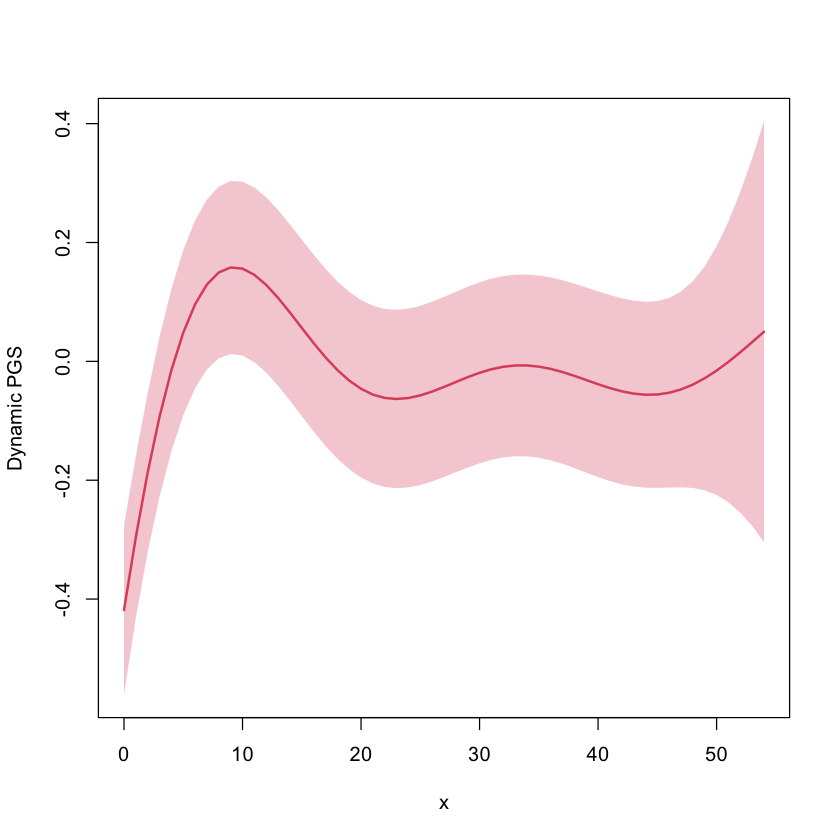

In [40]:
head(adata_with_pgs$PGS)
# plotting the estimated PGS for the 3rd sample
plot(adata_with_pgs,i=3)